This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [9]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [1]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [15]:
#dask imports
#from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

Make the dask cluster & client in accordance with resource avail and model size

In [16]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

In [10]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")

In [11]:
dat.table_type

'mpra_umiwise'

In [18]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

scMPRAforge: WARNING: [timed_fit] somebody took 0.81 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 0.85 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 0.86 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 0.88 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 0.97 seconds
scMPRAforge: WARNING: [timed_fit] blood took 1.00 seconds
scMPRAforge: WARNING: [timed_fit] brain took 1.08 seconds


In [ ]:
def undo_100(parameters):
    #nb : pretty straight forward, you expect value to be reduced 100 fold
    print(parameters.nb)
    #zi: you expect 
    # theta.... not sure

undo_100(primordial.by_cre_parameters.result())


{'nobody':                                                nb
C(cell_type)[blood] C(cell_type)[brain]          
1                   0                    1.770948
0                   1                    0.928007, 'somebody':                                                 nb
C(cell_type)[blood] C(cell_type)[brain]           
1                   0                    12.482239
0                   1                     9.956856, 'everybody':                                                  nb
C(cell_type)[blood] C(cell_type)[brain]            
1                   0                    103.464231
0                   1                    107.659933, 'redgene':                                                  nb
C(cell_type)[blood] C(cell_type)[brain]            
1                   0                    105.615668
0                   1                     30.747903, 'neurogene':                                                 nb
C(cell_type)[blood] C(cell_type)[brain]           
1             

In [6]:
batch=scm.simulation_batch(primordial)
batch.describe_primordial(client,dat)

In [8]:
batch.simulate_many(client,3)

In [ ]:
batch.fit_to_simulations(client)

scMPRAforge: WARNING: [timed_fit] nobody took 1.17 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.45 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.67 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 1.66 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.64 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 1.64 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 1.88 seconds
scMPRAforge: WARNING: [timed_fit] brain took 1.90 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.92 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.86 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 1.88 seconds
scMPRAforge: WARNING: [timed_fit] blood took 2.28 seconds
scMPRAforge: WARNING: [timed_fit] blood took 2.27 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.32 seconds
scMPRAforge: WARNING: [timed_fit] blood took 2.01 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.50 seconds
scMPRAforge: WARNING: [timed_fit] somebody 

scMPRAforge: WARNING: [timed_fit] neurogene took 2.18 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 1.88 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.25 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.58 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.40 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.83 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.15 seconds
scMPRAforge: WARNING: [timed_fit] nobody took 1.64 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.88 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 1.90 seconds
scMPRAforge: WARNING: [timed_fit] redgene took 2.08 seconds
scMPRAforge: WARNING: [timed_fit] neurogene took 2.14 seconds
scMPRAforge: WARNING: [timed_fit] somebody took 1.77 seconds
scMPRAforge: WARNING: [timed_fit] everybody took 1.93 seconds
scMPRAforge: WARNING: [timed_fit] brain took 2.18 seconds
scMPRAforge: WARNING: [timed_fit] blood took 2.26 seconds
scMPRAforge: WARNING: [timed_fit] everybody

In [10]:
batch._flatten_all_parameters()

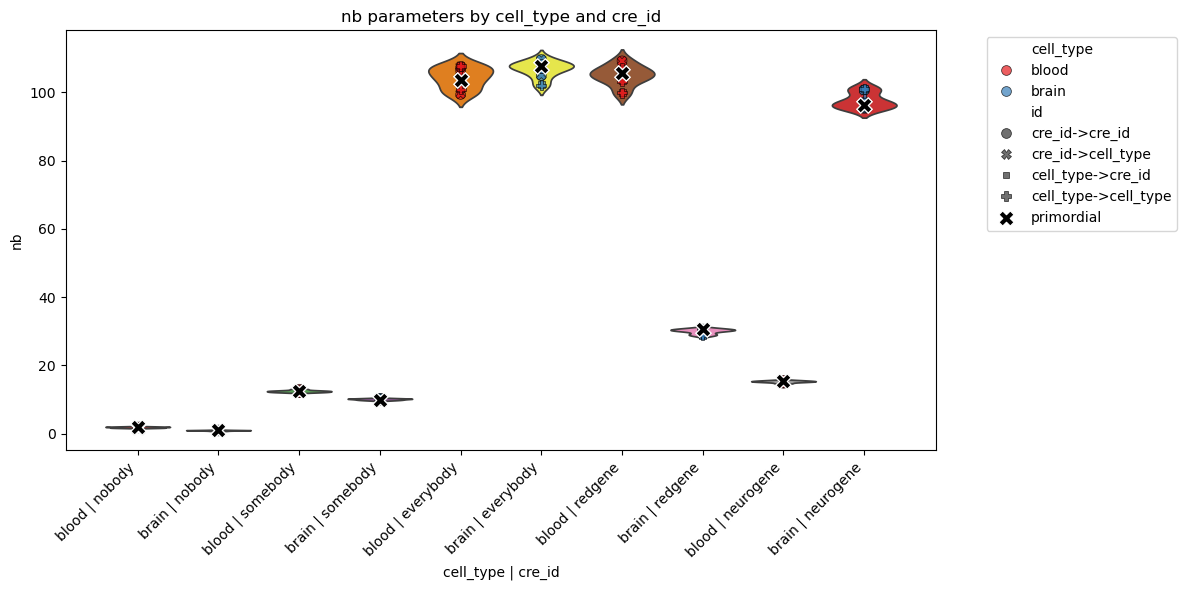

In [11]:
batch.plot_nb_spread()

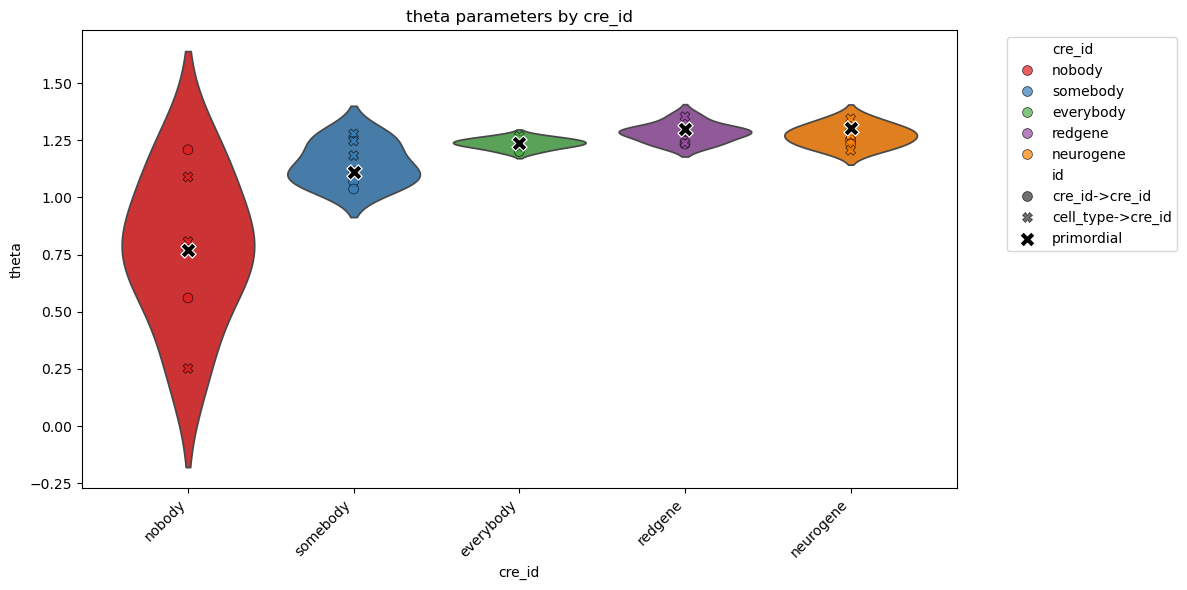

In [12]:
batch.plot_theta_spread("cre_id")

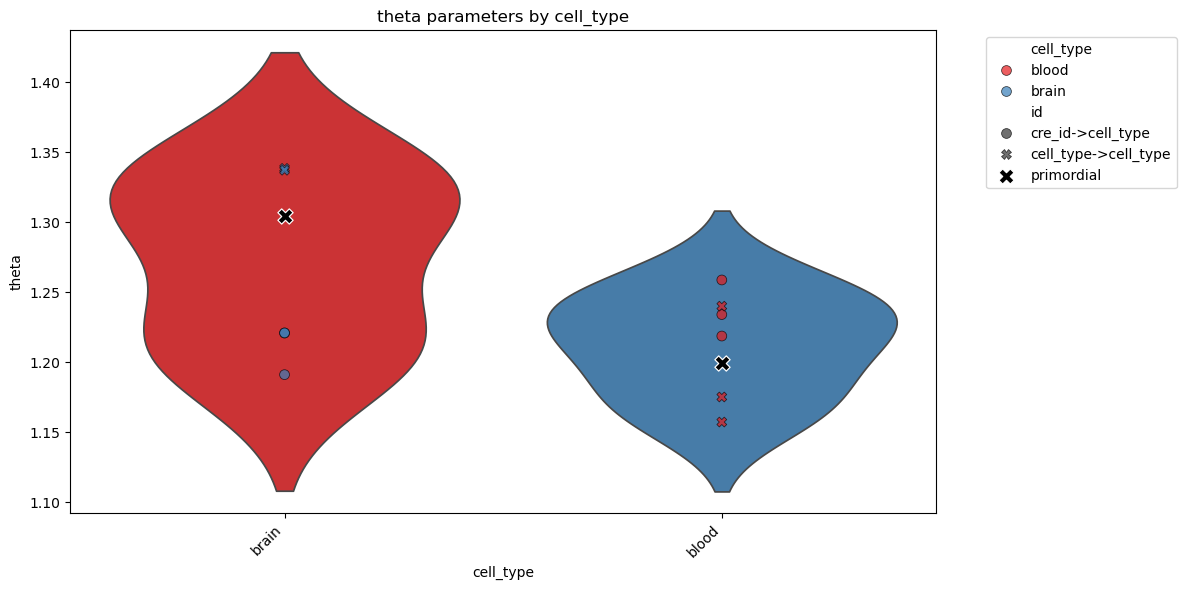

In [13]:
batch.plot_theta_spread("cell_type")

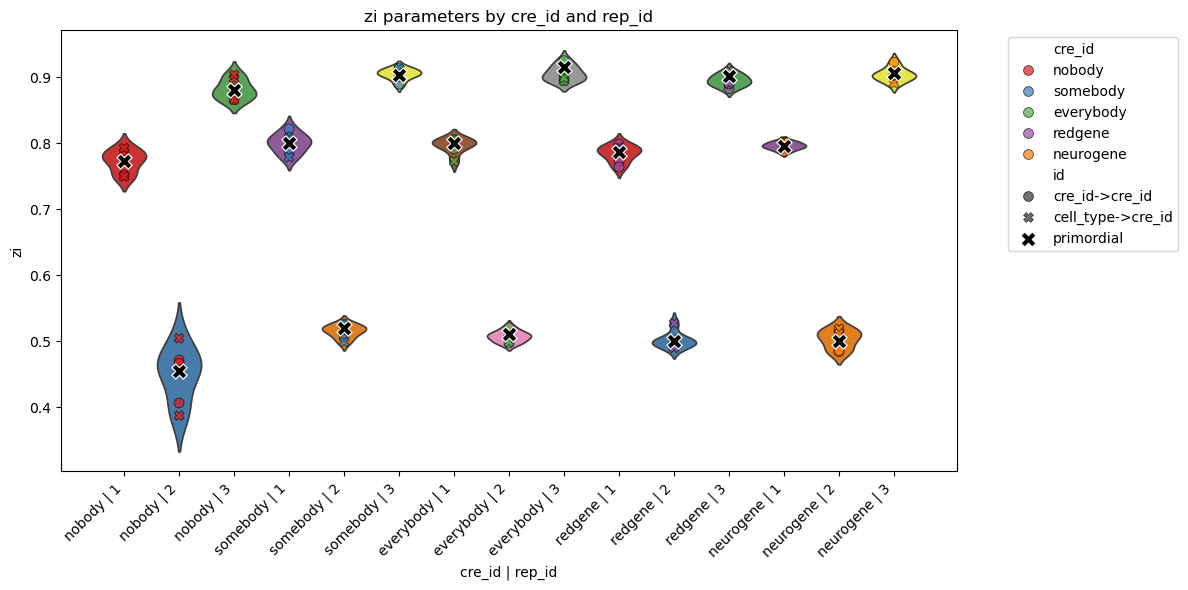

In [14]:
batch.plot_zi_spread("cre_id")

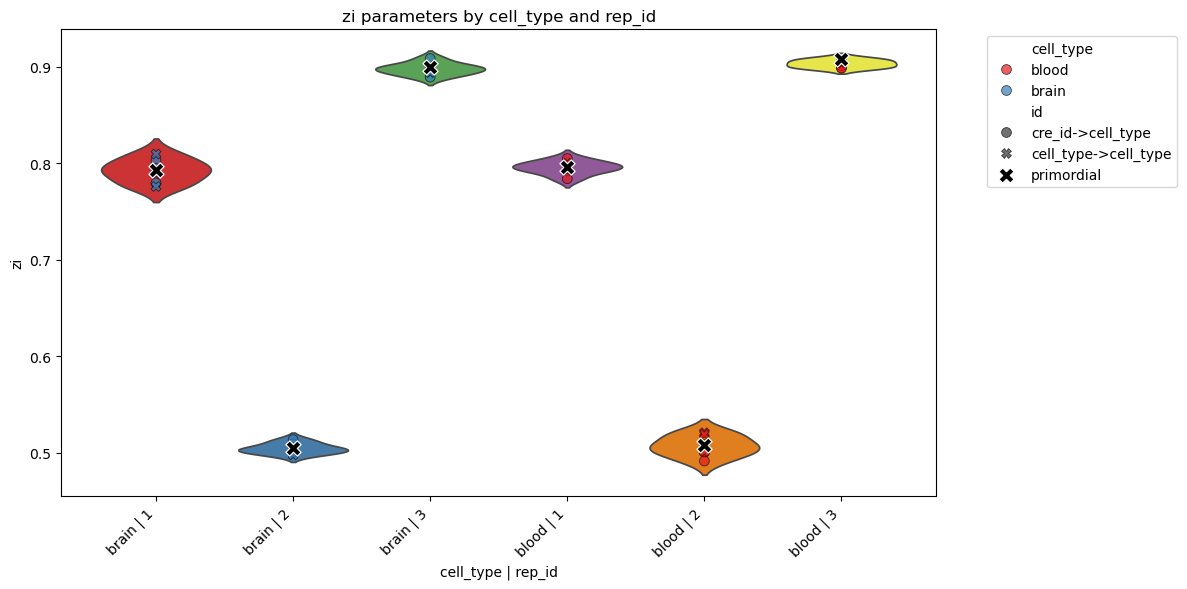

In [15]:
batch.plot_zi_spread("cell_type")

In [16]:
cluster.close()